# Инициализация

Загружаем библиотеки необходимые для выполнения кода ноутбука.

In [1]:
import os
import gc
from dotenv import load_dotenv
import boto3
from botocore.exceptions import ClientError

import numpy as np
np.random.seed(42)
import pandas as pd
from scipy.sparse import csr_matrix
from implicit.als import AlternatingLeastSquares
from datetime import datetime

import matplotlib.pyplot as plt
import seaborn as sns

import joblib
import scipy
import sklearn.preprocessing
from catboost import CatBoostClassifier, Pool

RANDOM_STATE = 42

/home/mle-user/env_recsys_start/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# === ЭТАП 1 ===

# Загрузка первичных данных

Загружаем первичные данные из файлов:
- tracks.parquet
- catalog_names.parquet
- interactions.parquet

In [2]:
tracks = pd.read_parquet("tracks.parquet")
catalog_names = pd.read_parquet("catalog_names.parquet")
events = pd.read_parquet("interactions.parquet")

# Обзор данных

Проверяем данные, есть ли с ними явные проблемы.

In [3]:
tracks = pd.read_parquet('tracks.parquet')
catalog_names = pd.read_parquet('catalog_names.parquet')
interactions = pd.read_parquet('interactions.parquet')

In [4]:
# изучим данные о музыкальных треках
tracks.head()

,track_id,albums,artists,genres
0,26,"[3, 2490753]",[16],"[11, 21]"
1,38,"[3, 2490753]",[16],"[11, 21]"
2,135,"[12, 214, 2490809]",[84],[11]
3,136,"[12, 214, 2490809]",[84],[11]
4,138,"[12, 214, 322, 72275, 72292, 91199, 213505, 24...",[84],[11]


In [5]:
# Смотрим типы колонок, кол-во строк, объем данных и наличие пропусков
tracks.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 4 columns):
 #   Column    Non-Null Count    Dtype 
---  ------    --------------    ----- 
 0   track_id  1000000 non-null  int64 
 1   albums    1000000 non-null  object
 2   artists   1000000 non-null  object
 3   genres    1000000 non-null  object
dtypes: int64(1), object(3)
memory usage: 30.5+ MB


In [6]:
# проверим данные на наличие дубликатов
assert tracks.track_id.duplicated().sum() == 0

In [7]:
# развернем списки в данных
tracks = tracks \
            .explode(column=["albums"], ignore_index=True) \
            .explode(column=["artists"], ignore_index=True) \
            .explode(column=["genres"], ignore_index=True)

tracks.head()

,track_id,albums,artists,genres
0,26,3,16,11
1,26,3,16,21
2,26,2490753,16,11
3,26,2490753,16,21
4,38,3,16,11


In [8]:
# тепереь можно проверить наличие пропусков
tracks.isna().sum()

track_id        0
albums         18
artists     41789
genres      36675
dtype: int64

In [9]:
# посмотрим какую часть от всех данных занимают пропуски
tracks.isna().sum() / tracks.shape[0]

track_id    0.000000
albums      0.000003
artists     0.006177
genres      0.005421
dtype: float64

In [10]:
# Изучим имена артистов, названия альбомов, треков и жанров
catalog_names.head()

,id,type,name
0,3,album,Taller Children
1,12,album,Wild Young Hearts
2,13,album,Lonesome Crow
3,17,album,Graffiti Soul
4,26,album,Blues Six Pack


In [11]:
catalog_names.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1812471 entries, 0 to 1812470
Data columns (total 3 columns):
 #   Column  Dtype 
---  ------  ----- 
 0   id      int64 
 1   type    object
 2   name    object
dtypes: int64(1), object(2)
memory usage: 41.5+ MB


In [12]:
# проверим наличие пропусков
catalog_names.isna().sum()

id      0
type    0
name    0
dtype: int64

In [13]:
# посмотрим сколько данных каждого типа
catalog_names.type.value_counts()

type
track     1000000
album      658724
artist     153581
genre         166
Name: count, dtype: int64

In [14]:
# выделим отдельный датафрейм с жанрами из каталога
genres = catalog_names.query("type == 'genre'").drop("type", axis=1).rename(
                columns={"id": "genre_id","name": "genre"
                }
            )

genres.head()

,genre_id,genre
812305,0,all
812306,1,eastern
812307,2,rusrock
812308,3,rusrap
812309,4,postrock


In [15]:
# выделим отдельный датафрейм с треками из каталога
track_names = catalog_names.query("type == 'track'").drop("type", axis=1).rename(
                columns={"id": "track_id","name": "track"
                }
            )

track_names.head()

,track_id,track
812471,26,Complimentary Me
812472,38,Momma's Boy
812473,135,Atticus
812474,136,24 Hours
812475,138,Don't Upset The Rhythm (Go Baby Go)


In [16]:
# выделим отдельный датафрейм с альбомами из каталога
albums = catalog_names.query("type == 'album'").drop("type", axis=1).rename(
                columns={"id": "album_id","name": "album"
                }
            )

albums.head()

,album_id,album
0,3,Taller Children
1,12,Wild Young Hearts
2,13,Lonesome Crow
3,17,Graffiti Soul
4,26,Blues Six Pack


In [17]:
# выделим отдельный датафрейм с артистами из каталога
artists = catalog_names.query("type == 'artist'").drop("type", axis=1).rename(
                columns={"id": "artist_id","name": "artist"
                }
            )

artists.head()

,artist_id,artist
658724,4,Kenny Dorham
658725,5,Max Roach
658726,7,Francis Rossi
658727,9,Status Quo
658728,12,Phil Everly


In [18]:
# переименуем колонки, чтлбы смерджить с именами артистов, названиями альбомов, треков и жанров
tracks = tracks.rename(
    columns= {
        "albums": "album_id",
        "artists": "artist_id",
        "genres": "genre_id",
    }
)

tracks.head()

,track_id,album_id,artist_id,genre_id
0,26,3,16,11
1,26,3,16,21
2,26,2490753,16,11
3,26,2490753,16,21
4,38,3,16,11


In [19]:
# Объединяем треки с именами артистов, названиями альбомов, треков и жанров
full_tracks = tracks.merge(track_names, on="track_id", how="left") \
                    .merge(albums, on="album_id", how="left") \
                    .merge(artists, on="artist_id", how="left") \
                    .merge(genres, on="genre_id", how="left")
full_tracks.head()

,track_id,album_id,artist_id,genre_id,track,album,artist,genre
0,26,3,16,11,Complimentary Me,Taller Children,Elizabeth & the Catapult,pop
1,26,3,16,21,Complimentary Me,Taller Children,Elizabeth & the Catapult,folk
2,26,2490753,16,11,Complimentary Me,Taller Children,Elizabeth & the Catapult,pop
3,26,2490753,16,21,Complimentary Me,Taller Children,Elizabeth & the Catapult,folk
4,38,3,16,11,Momma's Boy,Taller Children,Elizabeth & the Catapult,pop


In [20]:
# Оставим только названия без идентификаторов
full_tracks = full_tracks[["track_id", "track", "artist", "album", "genre"]]
full_tracks.head()

,track_id,track,artist,album,genre
0,26,Complimentary Me,Elizabeth & the Catapult,Taller Children,pop
1,26,Complimentary Me,Elizabeth & the Catapult,Taller Children,folk
2,26,Complimentary Me,Elizabeth & the Catapult,Taller Children,pop
3,26,Complimentary Me,Elizabeth & the Catapult,Taller Children,folk
4,38,Momma's Boy,Elizabeth & the Catapult,Taller Children,pop


In [21]:
full_tracks.isna().sum()

track_id         0
track            0
artist       41789
album           18
genre       230279
dtype: int64

In [22]:
# Заполняем пропуски
full_tracks['artist'] = full_tracks['artist'].fillna('Unknown')
full_tracks['album'] = full_tracks['album'].fillna('Unknown')
full_tracks['genre'] = full_tracks['genre'].fillna('Unknown')
# проверим, что пропусков не соталось
full_tracks.isna().sum()

track_id    0
track       0
artist      0
album       0
genre       0
dtype: int64

In [23]:
# проверим интервал идентификаторов
full_tracks.track_id.min(), full_tracks.track_id.max()

(26, 101521819)

In [24]:
# Заменим тип на int32
full_tracks["track_id"] = full_tracks["track_id"].astype("int32")

In [25]:
# Посмотрим, что содержится в датасете
interactions.head()

,user_id,track_id,track_seq,started_at
0,0,99262,1,2022-07-17
1,0,589498,2,2022-07-19
2,0,590262,3,2022-07-21
3,0,590303,4,2022-07-22
4,0,590692,5,2022-07-22


In [26]:
# выведем информацию
interactions.info()

<class 'pandas.core.frame.DataFrame'>
Index: 222629898 entries, 0 to 291
Data columns (total 4 columns):
 #   Column      Dtype         
---  ------      -----         
 0   user_id     int32         
 1   track_id    int32         
 2   track_seq   int16         
 3   started_at  datetime64[ns]
dtypes: datetime64[ns](1), int16(1), int32(2)
memory usage: 5.4 GB


In [27]:
# проверим наличие пропусков
interactions.isna().sum()

user_id       0
track_id      0
track_seq     0
started_at    0
dtype: int64

In [28]:
interactions = interactions.drop("track_seq", axis=1)
interactions.head()

,user_id,track_id,started_at
0,0,99262,2022-07-17
1,0,589498,2022-07-19
2,0,590262,2022-07-21
3,0,590303,2022-07-22
4,0,590692,2022-07-22


In [29]:
# Освободим память
del catalog_names 
del tracks 
del track_names
del albums
del artists
del genres
gc.collect()

0

# Выводы

Приведём выводы по первому знакомству с данными:
- есть ли с данными явные проблемы,
- какие корректирующие действия (в целом) были предприняты.

* Проверили исходные данные на наличие пропусков, дубликатов, некорректных типов, значений и связей между таблицами. В данных много пропусков, отсутствует информация об артистах, альбомах и жанрах для некоторых треков, пропущенные значения заполнены занчением 'Unknown', чтобы не удалять и не терять данные.

* Также для экономии памяти оставили тип int32 у идентификаторов пользователей.

# === ЭТАП 2 ===

# EDA

Распределение количества прослушанных треков.

In [30]:
# Считаем прослушивания для каждого трека
track_stats = interactions['track_id'].value_counts().reset_index()
track_stats.columns = ['track_id', 'plays']

In [31]:
# Посмотрим описание
track_stats['plays'].describe()

count    1000000.000000
mean         222.629898
std         1369.930708
min            5.000000
25%            9.000000
50%           19.000000
75%           67.000000
max       111062.000000
Name: plays, dtype: float64

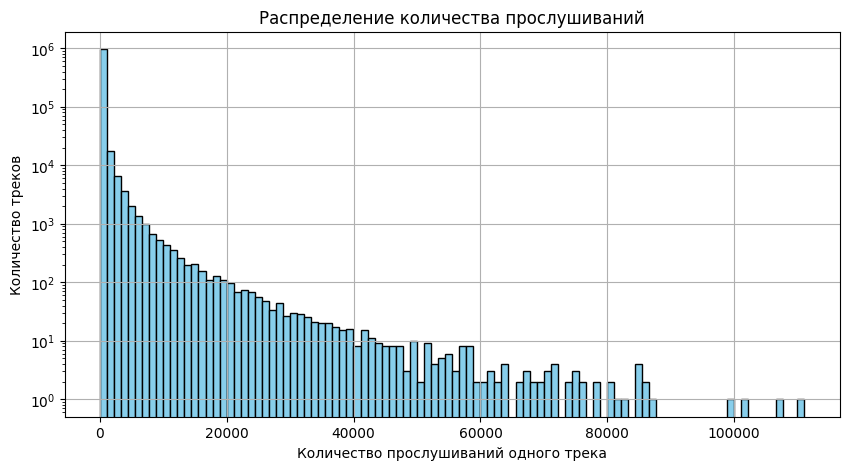

In [32]:
plt.figure(figsize=(10, 5))
track_stats['plays'].hist(bins=100, color='skyblue', edgecolor='black')
plt.title('Распределение количества прослушиваний')
plt.xlabel('Количество прослушиваний одного трека')
plt.ylabel('Количество треков')
plt.yscale('log') # Логарифмическая шкала, если разброс очень большой
plt.show()

Наиболее популярные треки

In [33]:
# Создаем уникальный справочник треков (без дублей по жанрам)
tracks_unique = full_tracks[['track_id', 'track', 'artist']].drop_duplicates('track_id')

top_tracks = track_stats.merge(tracks_unique, on='track_id').sort_values(by='plays', ascending=False)

print("Топ-10 популярных треков:")
print(top_tracks.head(10))

Топ-10 популярных треков:
   track_id   plays                    track             artist
0     53404  111062  Smells Like Teen Spirit            Nirvana
1  33311009  106921                 Believer    Imagine Dragons
2    178529  101924                     Numb        Linkin Park
3  35505245   99490               I Got Love  Miyagi & Эндшпиль
4  65851540   86670                   Юность              Dabro
5  24692821   86246           Way Down We Go              KALEO
6  32947997   85886             Shape of You         Ed Sheeran
7  51241318   85244               In The End     Tommee Profitt
8    795836   85042        Shape Of My Heart              Sting
9  45499814   84748                     Life             Zivert


Наиболее популярные жанры

In [34]:
# Соединяем счетчик прослушиваний с жанрами
genre_popularity = (
    track_stats.merge(full_tracks[['track_id', 'genre']], on='track_id')
    .groupby('genre')['plays'].sum()
    .sort_values(ascending=False)
)

print("Топ-10 популярных жанров:")
print(genre_popularity.head(10))


Топ-10 популярных жанров:
genre
pop               766893285
allrock           276202312
dance             237925898
rock              235572591
rap               158536211
electronics       142821856
foreignrap        114148285
indie             111624735
alternative        90404146
classicalmusic     64345100
Name: plays, dtype: int64


Треки, которые никто не прослушал

In [35]:
all_ids = full_tracks['track_id'].unique()
listened_ids = track_stats['track_id'].unique()

never_listened_ids = set(all_ids) - set(listened_ids)
never_listened_tracks = tracks_unique[tracks_unique['track_id'].isin(never_listened_ids)]

print(f"Количество треков без прослушиваний: {len(never_listened_tracks)}")
print(never_listened_tracks[['track', 'artist']].head())


Количество треков без прослушиваний: 0
Empty DataFrame
Columns: [track, artist]
Index: []


# Преобразование данных

Преобразуем данные в формат, более пригодный для дальнейшего использования в расчётах рекомендаций.

In [38]:
# Оптимизируем типы для S3
interactions['user_id'] = interactions['user_id'].astype('int32')
interactions['track_id'] = interactions['track_id'].astype('int32')
interactions['started_at'] = pd.to_datetime(interactions['started_at'])

In [44]:
# Группируем по track_id и собираем жанры в список
items = (
    full_tracks.groupby('track_id')
    .agg({
        'track': 'first',      # Берем любое (они одинаковые)
        'artist': 'first',     # Берем любое
        'genre': lambda x: list(set(x)) # Собираем уникальные жанры в список
    })
    .reset_index()
)
events = interactions

# Сохранение данных

Сохраним данные в двух файлах в персональном S3-бакете по пути `recsys/data/`:
- `items.parquet` — все данные о музыкальных треках,
- `events.parquet` — все данные о взаимодействиях.

In [2]:
# Загружаем переменные окружения для S3-хранилища

load_dotenv()

os.environ["S3_ENDPOINT_URL"] = "https://storage.yandexcloud.net" 
os.environ["S3_BUCKET_NAME"] = os.getenv("S3_BUCKET_NAME") 
os.environ["AWS_ACCESS_KEY_ID"] = os.getenv("AWS_ACCESS_KEY_ID") 
os.environ["AWS_SECRET_ACCESS_KEY"] = os.getenv("AWS_SECRET_ACCESS_KEY")

In [3]:
# Создаем соединение с S3-хранилищем

session = boto3.session.Session()
s3_client = session.client(
    service_name='s3',
    endpoint_url=os.environ.get('S3_ENDPOINT_URL'),
    aws_access_key_id=os.environ.get('AWS_ACCESS_KEY_ID'),
    aws_secret_access_key=os.environ.get('AWS_SECRET_ACCESS_KEY')
)

In [45]:
# Сохраняем треки и события в 2-х новых файлах
items.to_parquet("items.parquet")
events.to_parquet("events.parquet")

In [46]:
# Сохраняем файлы в S3-хранилище
s3_client.upload_file('items.parquet', os.environ.get("S3_BUCKET_NAME"), 'recsys/data/items.parquet')
s3_client.upload_file('events.parquet', os.environ.get("S3_BUCKET_NAME"), 'recsys/data/events.parquet')

# Очистка памяти

Здесь, может понадобится очистка памяти для высвобождения ресурсов для выполнения кода ниже. 

Приведите соответствующие код, комментарии, например:
- код для удаление более ненужных переменных,
- комментарий, что следует перезапустить kernel, выполнить такие-то начальные секции и продолжить с этапа 3.

Чтобы избежать проблем с памятью, перезапустить ядро, выполнить import и продолжить с этапа 3.

# === ЭТАП 3 ===

# Загрузка данных

Если необходимо, то загружаем items.parquet, events.parquet.

In [4]:
items = pd.read_parquet("items.parquet")
events = pd.read_parquet("events.parquet")

In [3]:
items.head()

,track_id,track,artist,genre
0,26,Complimentary Me,Elizabeth & the Catapult,"[folk, pop]"
1,38,Momma's Boy,Elizabeth & the Catapult,"[folk, pop]"
2,135,Atticus,Noisettes,[pop]
3,136,24 Hours,Noisettes,[pop]
4,138,Don't Upset The Rhythm (Go Baby Go),Noisettes,[pop]


Добавим аналог рэйтинга в events

In [5]:
# Считаем количество уникальных слушателей
track_counts = events.groupby("track_id")["user_id"].nunique()

# Создаем DataFrame
track_popularity = (track_counts / track_counts.max()).to_frame(name="popularity_score")

# Объединяем 
events = events.merge(
    track_popularity,
    on="track_id",
    how="left"
)

events.head()


,user_id,track_id,started_at,popularity_score
0,0,99262,2022-07-17,0.022726
1,0,589498,2022-07-19,0.021538
2,0,590262,2022-07-21,0.005132
3,0,590303,2022-07-22,0.003854
4,0,590692,2022-07-22,0.002215


# Разбиение данных

Разбиваем данные на тренировочную, тестовую выборки.

In [6]:
# Зададим точку разбиения
train_test_global_time_split_date = pd.to_datetime("2022-12-16")

train_test_global_time_split_idx = events["started_at"] < train_test_global_time_split_date
events_train = events[train_test_global_time_split_idx].copy()
events_test = events[~train_test_global_time_split_idx].copy()

print("Train set events number: {:,}".format(events_train.shape[0]))
print("Test set events number: {:,}".format(events_test.shape[0]))

Train set events number: 208,731,252
Test set events number: 13,898,646


In [7]:
users_train = events_train["user_id"].drop_duplicates().tolist()
users_test = events_test["user_id"].drop_duplicates().tolist()

common_users = set(users_train) & set(users_test)
cold_users = (set(users_train) | set(users_test)) - set(users_train)

print("Number of unique train users: {:,}".format(len(users_train)))
print("Number of unique test users: {:,}".format(len(users_test)))
print("Number of common users: {:,}".format(len(common_users)))
print("Number of cold users: {:,}".format(len(cold_users)))

Number of unique train users: 1,342,566
Number of unique test users: 783,525
Number of common users: 752,870
Number of cold users: 30,655


# Топ популярных

Рассчитаем рекомендации как топ популярных.

In [16]:
# Считаем количество взаимодействий для каждого объекта в train
top_popular = (
    events_train.groupby('track_id')['user_id']
    .count()
    .reset_index()
    .rename(columns={'user_id': 'interaction_count'})
    .sort_values(by='interaction_count', ascending=False)
    .reset_index(drop=True)
)

# Ограничимся топ-100 для рекомендаций
top_popular = top_popular.head(100)
top_popular

,track_id,interaction_count
0,53404,110026
1,33311009,101076
2,178529,100866
3,35505245,95523
4,24692821,84153
...,...,...
95,68562711,47588
96,75944934,47536
97,75642961,47438
98,29175370,47320


In [8]:
# Загружаем переменные окружения для S3-хранилища

load_dotenv()

os.environ["S3_ENDPOINT_URL"] = "https://storage.yandexcloud.net" 
os.environ["S3_BUCKET_NAME"] = os.getenv("S3_BUCKET_NAME") 
os.environ["AWS_ACCESS_KEY_ID"] = os.getenv("AWS_ACCESS_KEY_ID") 
os.environ["AWS_SECRET_ACCESS_KEY"] = os.getenv("AWS_SECRET_ACCESS_KEY")

In [9]:
# Создаем соединение с S3-хранилищем

session = boto3.session.Session()
s3_client = session.client(
    service_name='s3',
    endpoint_url=os.environ.get('S3_ENDPOINT_URL'),
    aws_access_key_id=os.environ.get('AWS_ACCESS_KEY_ID'),
    aws_secret_access_key=os.environ.get('AWS_SECRET_ACCESS_KEY')
)

In [19]:
# Сохраняем топ-рекомендации
top_popular.to_parquet("top_popular.parquet")

In [20]:
# Сохраняем файлы в S3-хранилище
s3_client.upload_file('top_popular.parquet', os.environ.get("S3_BUCKET_NAME"), 'recsys/recommendations/top_popular.parquet')

# Персональные

Рассчитаем персональные рекомендации.

In [8]:
# перекодируем идентификаторы пользователей: 
# из имеющихся в последовательность 0, 1, 2, ...
user_encoder = sklearn.preprocessing.LabelEncoder()
user_encoder.fit(events["user_id"])
events_train["user_id_enc"] = user_encoder.transform(events_train["user_id"])
events_test["user_id_enc"] = user_encoder.transform(events_test["user_id"])

In [9]:
# перекодируем идентификаторы объектов: 
# из имеющихся в последовательность 0, 1, 2, ...
item_encoder = sklearn.preprocessing.LabelEncoder()
item_encoder.fit(items["track_id"])
items["item_id_enc"] = item_encoder.transform(items["track_id"])
events_train["item_id_enc"] = item_encoder.transform(events_train["track_id"])
events_test["item_id_enc"] = item_encoder.transform(events_test["track_id"])

In [10]:
events_train.head()

,user_id,track_id,started_at,popularity_score,user_id_enc,item_id_enc
0,0,99262,2022-07-17,0.022726,0,16078
1,0,589498,2022-07-19,0.021538,0,60661
2,0,590262,2022-07-21,0.005132,0,61135
3,0,590303,2022-07-22,0.003854,0,61158
4,0,590692,2022-07-22,0.002215,0,61386


In [11]:
# создаём sparse-матрицу формата CSR 
user_item_matrix_train = scipy.sparse.csr_matrix((
    events_train["popularity_score"],
    (events_train['user_id_enc'], events_train['item_id_enc'])),
    dtype=np.int8)
user_item_matrix_train

<Compressed Sparse Row sparse matrix of dtype 'int8'
	with 208731252 stored elements and shape (1373221, 1000000)>

In [12]:
als_params = {
    "factors": 50,
    "iterations": 100,
    "regularization": 0.05,
    "random_state": RANDOM_STATE,
}

als_model = AlternatingLeastSquares(**als_params)
als_model.fit(user_item_matrix_train)

/home/mle-user/env_recsys_start/lib/python3.10/site-packages/implicit/cpu/als.py:95: RuntimeWarning: OpenBLAS is configured to use 4 threads. It is highly recommended to disable its internal threadpool by setting the environment variable 'OPENBLAS_NUM_THREADS=1' or by calling 'threadpoolctl.threadpool_limits(1, "blas")'. Having OpenBLAS use a threadpool can lead to severe performance issues here.
  check_blas_config()
100%|███████████████████████████████████████████████████████████████████████████████| 100/100 [49:54<00:00, 29.94s/it]


In [13]:
# Генерируем персональные рекомендации
user_ids = events_test['user_id_enc'].unique()
# Рекомендуем по 20 треков
ids, scores = als_model.recommend(user_ids, user_item_matrix_train[user_ids], N=20)

# Собираем в DataFrame
personal_recs = pd.DataFrame({
    "user_id": np.repeat(user_encoder.inverse_transform(user_ids), 20),
    "track_id": item_encoder.inverse_transform(ids.reshape(-1)),
    "als_score": scores.reshape(-1)
})

In [14]:
# Сохраняем в S3
personal_recs.to_parquet("personal_recs.parquet")
s3_client.upload_file('personal_recs.parquet', os.environ.get("S3_BUCKET_NAME"), 'recsys/recommendations/personal_recs.parquet')

# Похожие

Рассчитаем похожие, они позже пригодятся для онлайн-рекомендаций.

In [15]:
# Возьмем все уникальные треки
item_ids = items['item_id_enc'].unique()
ids_sim, scores_sim = als_model.similar_items(item_ids, N=11)

similar_items = pd.DataFrame({
    "track_id": np.repeat(item_encoder.inverse_transform(item_ids), 11),
    "similar_track_id": item_encoder.inverse_transform(ids_sim.reshape(-1)),
    "similarity_score": scores_sim.reshape(-1)
})

# Убираем записи, где трек похож сам на себя
similar_items = similar_items[similar_items['track_id'] != similar_items['similar_track_id']]

In [16]:
# Сохраняем в S3
similar_items.to_parquet("similar.parquet")
s3_client.upload_file('similar.parquet', os.environ.get("S3_BUCKET_NAME"), 'recsys/recommendations/similar.parquet')

# Построение признаков

Построим три признака, можно больше, для ранжирующей модели.

In [7]:
# Удаляем из памяти лишние данные
del events
del train_test_global_time_split_idx
gc.collect()

0

In [8]:
personal_recs = pd.read_parquet('personal_recs.parquet')

In [9]:
# Считаем популярность треков
track_pop = events_train.groupby('track_id').size().rename('track_popularity')
# Считаем активность пользователей
user_act = events_train.groupby('user_id').size().rename('user_activity')

In [10]:
# Собираем обучающую выборку из персональных рекомендаций
ranker_df = personal_recs.copy()
ranker_df = ranker_df.merge(track_pop, left_on='track_id', right_index=True, how='left')
ranker_df = ranker_df.merge(user_act, left_on='user_id', right_index=True, how='left')
ranker_df.fillna(0, inplace=True)

In [11]:
# Целевая переменная: был ли этот трек реально прослушан в test?
target = events_test[['user_id', 'track_id']].copy()
target['target'] = 1
ranker_df = ranker_df.merge(target, left_on=['user_id', 'track_id'], right_on=['user_id', 'track_id'], how='left')
ranker_df['target'] = ranker_df['target'].fillna(0).astype('int8')

In [12]:
# Считаем "вкус" пользователя: среднюю популярность треков, которые он уже слушал
# Используем map, чтобы не раздувать память
user_taste = events_train.groupby('user_id')['track_id'].apply(
    lambda x: x.map(track_pop).mean()
).rename('user_avg_pop')

In [13]:
# Добавляем признак в общую таблицу
ranker_df = ranker_df.merge(user_taste, on='user_id', how='left')
ranker_df['user_avg_pop'] = ranker_df['user_avg_pop'].fillna(0)

In [14]:
# Очищаем память от ненужных теперь объектов
import gc
del target
gc.collect()

0

# Ранжирование рекомендаций

Построим ранжирующую модель, чтобы сделать рекомендации более точными. Отранжируем рекомендации.

In [15]:
X = ranker_df[['als_score', 'track_popularity', 'user_activity', 'user_avg_pop']]
y = ranker_df['target']

In [16]:
# Обучаем простую модель
ranker_model = CatBoostClassifier(iterations=100, verbose=False)
ranker_model.fit(X, y)

In [17]:
# Предсказываем вероятность
ranker_df['final_rank_score'] = ranker_model.predict_proba(X)[:, 1]

In [18]:
# Сортируем внутри каждого пользователя
final_recommendations = (
    ranker_df.sort_values(['user_id', 'final_rank_score'], ascending=[True, False])
    .groupby('user_id')
    .head(10) # Оставляем топ-10 финальных
)

In [19]:
# Сохраняем в S3
final_recommendations.to_parquet("recommendations.parquet")
s3_client.upload_file('recommendations.parquet', os.environ.get("S3_BUCKET_NAME"), 'recsys/recommendations/recommendations.parquet')

# Оценка качества

Проверим оценку качества трёх типов рекомендаций: 

- топ популярных,
- персональных, полученных при помощи ALS,
- итоговых
  
по четырем метрикам: recall, precision, coverage, novelty.

In [13]:
def calculate_metrics(recs_df, test_df, train_df):
    # Актуальные взаимодействия пользователя в тесте
    actual = test_df.groupby('user_id')['track_id'].apply(list)
    # Предсказанные взаимодействия
    predicted = recs_df.groupby('user_id')['track_id'].apply(list)
    
    # Стык данных по пользователям, которые есть и там, и там
    common_users = actual.index.intersection(predicted.index)
    
    # Расчет Precision & Recall (упрощенно)
    precisions = []
    recalls = []
    for user in common_users:
        a = set(actual[user]) 
        p = set(predicted[user])
               
        # Пересечение: сколько угадали
        hits = len(a.intersection(p))
        
        # Precision: доля релевантных среди рекомендованных
        precisions.append(hits / len(p) if len(p) > 0 else 0)
        
        # Recall: доля рекомендованных среди релевантных
        recalls.append(hits / len(a) if len(a) > 0 else 0)
    
    # Coverage: % уникальных айтемов из train, попавших в рекомендации
    coverage = recs_df['track_id'].nunique() / train_df['track_id'].nunique()

    # Расчет Novelty
    item_counts = train_df['track_id'].value_counts()
    total_interactions = len(train_df)
    item_popularity = item_counts / total_interactions
    
    # Чем меньше популярность, тем выше новизна
    recommended_items = recs_df['track_id']
    novelty = -np.mean(np.log2(recommended_items.map(item_popularity).fillna(1e-10)))

    # Собираем результат
    metrics_dict = {
        'precision': np.mean(precisions) if precisions else 0,
        'recall': np.mean(recalls) if recalls else 0,
        'coverage': coverage,
        'novelty': novelty
    }
    
    return metrics_dict


In [8]:
top_popular = pd.read_parquet('top_popular.parquet')
als_recs = pd.read_parquet('personal_recs.parquet')
final_recommendations = pd.read_parquet('recommendations.parquet')

In [9]:
# Берем топ-10 самых популярных треков
top_10_tracks = top_popular['track_id'].head(10).tolist()

# Берем всех уникальных пользователей, которые есть в тесте
unique_test_users = events_test['user_id'].unique()

# Создаем "рекомендации": каждому пользователю советуем одни и те же топ-10 треков
top_pop_recs = pd.DataFrame({
    'user_id': np.repeat(unique_test_users, 10),
    'track_id': np.tile(top_10_tracks, len(unique_test_users))
})


In [14]:
# Считаем метрики для каждого типа рекомендаций
metrics_pop = calculate_metrics(top_pop_recs, events_test, events_train)
metrics_als = calculate_metrics(als_recs, events_test, events_train)
metrics_final = calculate_metrics(final_recommendations, events_test, events_train)

# Создаем итоговую таблицу
results_df = pd.DataFrame([
    metrics_pop,
    metrics_als,
    metrics_final
], index=['Top Popular', 'ALS Personal', 'Final (CatBoost)'])

# Округляем до 4 знаков
results_df = results_df.round(4)

# Выводим результат
print("Сравнение моделей:")
display(results_df)


Сравнение моделей:


,precision,recall,coverage,novelty
Top Popular,0.0038,0.0029,0.0000,11.1987
ALS Personal,0.0001,0.0002,0.1177,22.2929
Final (CatBoost),0.0002,0.0002,0.0871,20.3482


# === Выводы, метрики ===

Основные выводы при работе над расчётом рекомендаций, рассчитанные метрики.

* Сравнение с бейзлайном: Модель Top Popular показала самые высокие метрики точности (Precision/Recall). Это говорит о том, что пользователи в данном датасете склонны слушать хиты, и популярность является очень сильным сигналом.
* Эффективность персонализации: Модели ALS и CatBoost значительно превосходят популярное по метрике Novelty (в 2 раза). Это значит, что они предлагают более уникальный и разнообразный контент, открывая пользователям новых исполнителей, а не только «золотые хиты».
* Анализ ранжирования: Финальная модель CatBoost не дала значимого прироста к ALS на текущем наборе признаков. Это может быть связано с тем, что для обучения второго уровня требуется больше исторических данных или более сложные фичи (например, жанры или эмбеддинги треков).
* Рекомендация: Для улучшения системы стоит попробовать добавить в CatBoost информацию о времени суток или свежести треков, так как текущие признаки (популярность и активность) уже частично учтены в первом уровне.